# Lab Segmentation 2

In [31]:
from commonfunctions import *
import skimage.io as io
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


EXPERIMENT 1: Automatic Adaptive Thresholding

cameraman.png:
  Calculated Threshold: 89
  Iterations: 5

cufe.png:
  Calculated Threshold: 143
  Iterations: 4

book1.png:
  Calculated Threshold: 144
  Iterations: 6

book.png:
  Calculated Threshold: 138
  Iterations: 3


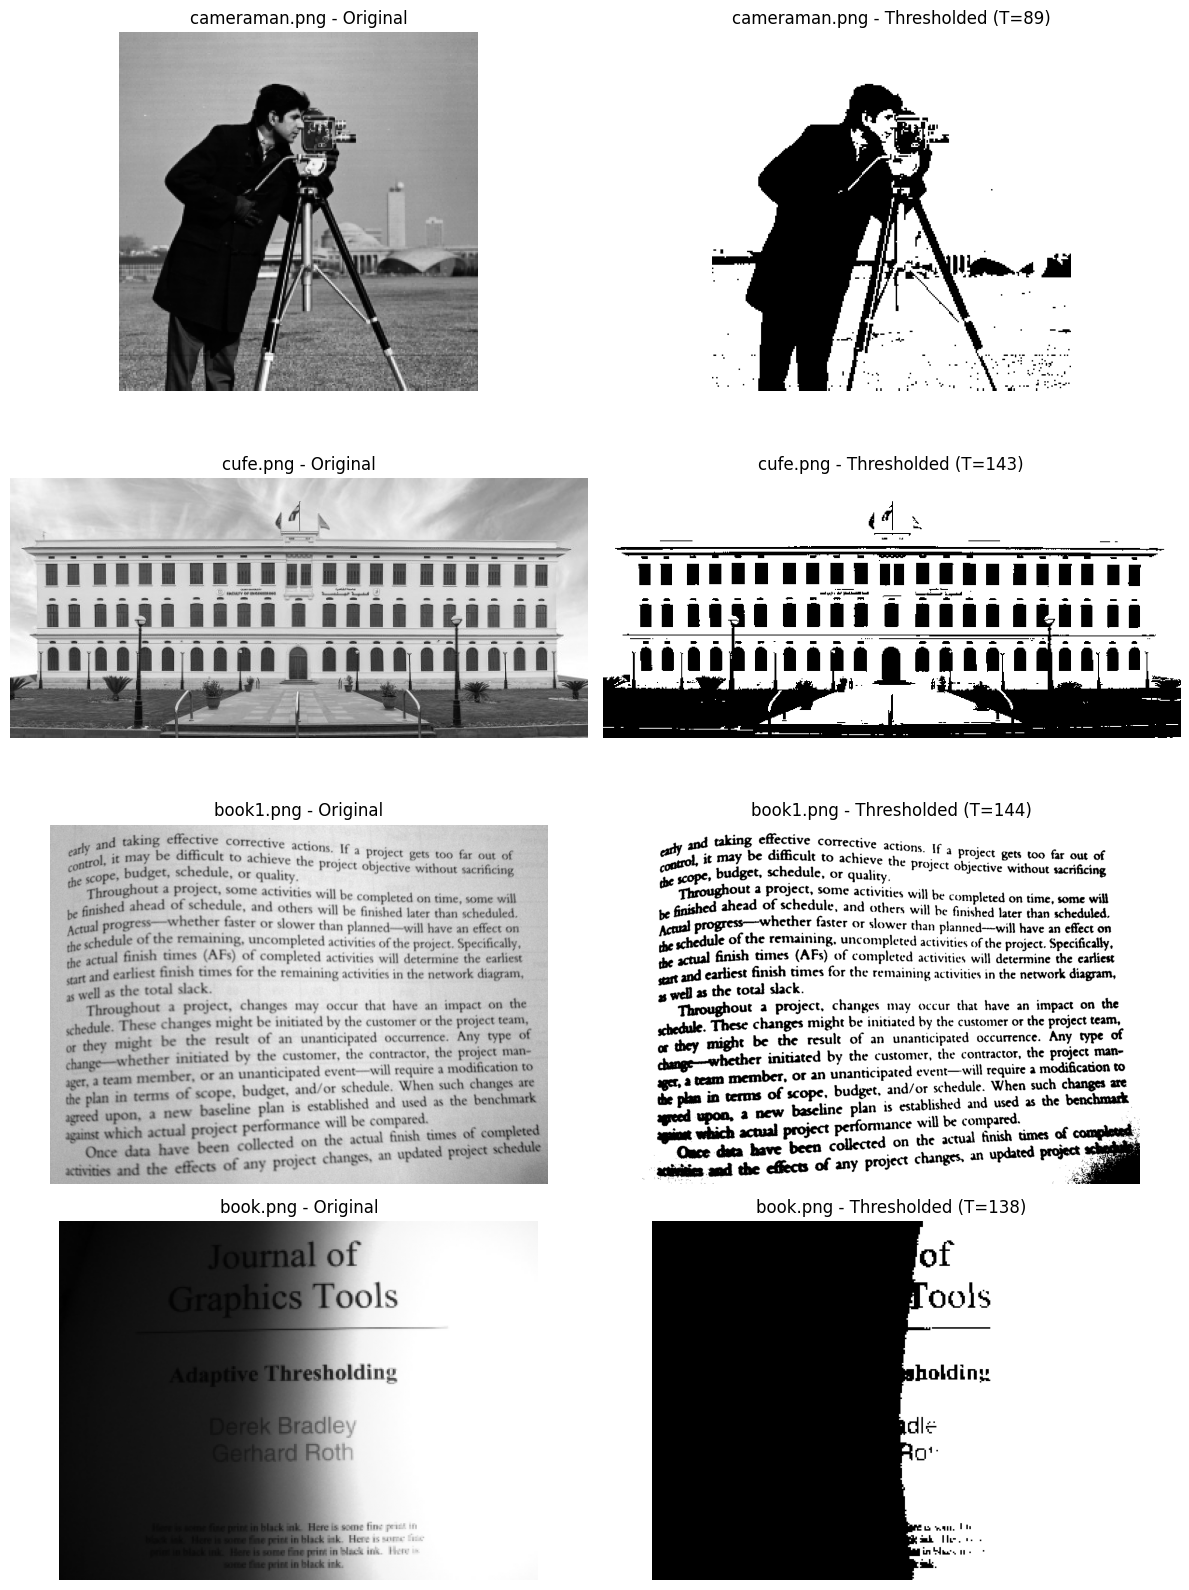

In [35]:
# Experiment 1: Implement Adaptive Thresholding Function

def getThreshold(image):
    """
    Implements histogram-based automatic thresholding technique.
    
    Parameters:
    image: input image (can be float or uint8)
    
    Returns:
    threshold: the calculated threshold value
    binary_image: the thresholded binary image (0 and 255)
    """
    
    # 1- Convert the image to uint8
    if image.dtype != np.uint8:
        img_uint8 = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)
    else:
        img_uint8 = image.copy()
    
    # 2- Get counts array (histogram)
    hist_data = histogram(img_uint8, nbins=256)
    counts = hist_data[0]  # Number of pixels at each grey level
    grey_levels = hist_data[1]  # Get the actual grey levels from histogram
    
    # # Ensure we have 256 grey levels
    # if len(counts) < 256:
    #     # Pad counts array to 256 if necessary
    #     padded_counts = np.zeros(256)
    #     padded_counts[:len(counts)] = counts
    #     counts = padded_counts
    #     grey_levels = np.arange(0, 256)
    # else:
    #     grey_levels = np.arange(0, len(counts))
    
    # 3- Get initial threshold as the average mean of pixels' grey-level
    total_pixels = np.sum(counts)  # Total number of pixels
    
    # Calculate weighted sum: sum(grey_level_k * number_of_pixels_k)
    weighted_sum = np.sum(grey_levels * counts)
    T_init = round(weighted_sum / total_pixels)
    
    # 4 & 5 & 6- Iteratively update threshold until saturation
    threshold = T_init
    prev_threshold = -1
    iteration = 0
    max_iterations = 100  # Prevent infinite loops
    
    while threshold != prev_threshold and iteration < max_iterations:
        prev_threshold = threshold
        
        # Get pixels in lower and upper groups
        lower_mask = grey_levels <= threshold
        upper_mask = grey_levels > threshold
        
        # Calculate mean for lower pixels
        if np.sum(counts[lower_mask]) > 0:
            lower_mean = np.sum(grey_levels[lower_mask] * counts[lower_mask]) / np.sum(counts[lower_mask])
        else:
            lower_mean = 0
        
        # Calculate mean for upper pixels
        if np.sum(counts[upper_mask]) > 0:
            upper_mean = np.sum(grey_levels[upper_mask] * counts[upper_mask]) / np.sum(counts[upper_mask])
        else:
            upper_mean = 255
        
        # Update threshold as average of the two means
        threshold = round((lower_mean + upper_mean) / 2)
        iteration += 1
    
    # Create binary image: pixels < threshold = 0 (black), pixels >= threshold = 255 (white)
    binary_image = np.where(img_uint8 < threshold, 0, 255).astype(np.uint8)
    
    return threshold, binary_image, iteration


# Test the function on the provided images
print("=" * 60)
print("EXPERIMENT 1: Automatic Adaptive Thresholding")
print("=" * 60)

# Test images to process
test_images = [
    'cameraman.png',
    'cufe.png',
    'book1.png',
    'book.png'
]

results_exp1 = {}

for img_path in test_images:
    try:
        # Read image
        img = io.imread(img_path)
        
        # Convert to grayscale if RGB
        if len(img.shape) == 3:
            img = rgb2gray(img)
        
        # Get threshold and binary image
        threshold, binary_img, iterations = getThreshold(img)
        results_exp1[img_path] = {
            'original': img,
            'binary': binary_img,
            'threshold': threshold,
            'iterations': iterations
        }
        
        print(f"\n{img_path}:")
        print(f"  Calculated Threshold: {threshold}")
        print(f"  Iterations: {iterations}")
        
    except FileNotFoundError:
        print(f"\nWarning: {img_path} not found")

# Display results for Experiment 1
fig, axes = plt.subplots(len(results_exp1), 2, figsize=(12, 4*len(results_exp1)))

if len(results_exp1) == 1:
    axes = axes.reshape(1, -1)

for idx, (img_path, data) in enumerate(results_exp1.items()):
    img_name = img_path.split('/')[-1]
    
    # Original image
    axes[idx, 0].imshow(data['original'], cmap='gray')
    axes[idx, 0].set_title(f'{img_name} - Original')
    axes[idx, 0].axis('off')
    
    # Thresholded image
    axes[idx, 1].imshow(data['binary'], cmap='gray')
    axes[idx, 1].set_title(f'{img_name} - Thresholded (T={data["threshold"]})')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)


EXPERIMENT 2: Local Adaptive Thresholding
  Top-Left Quarter - Threshold: 46
  Top-Right Quarter - Threshold: 186
  Bottom-Left Quarter - Threshold: 51
  Bottom-Right Quarter - Threshold: 197

Global Threshold for book.png: 138


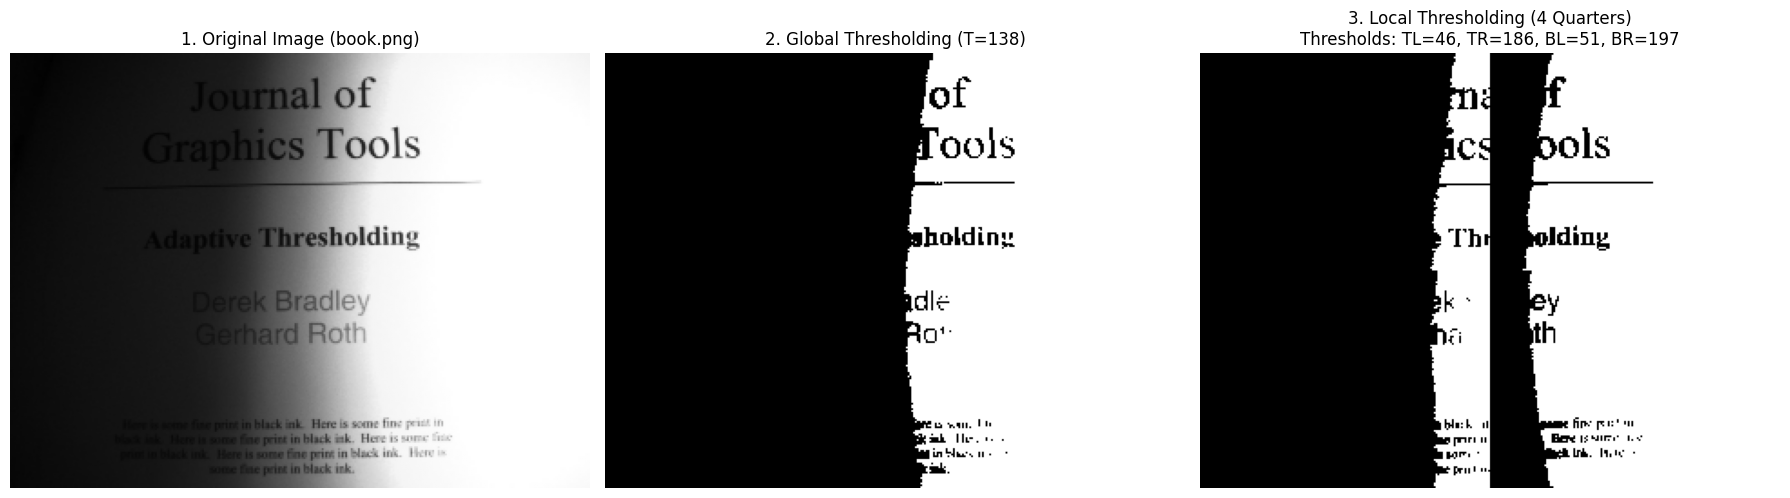

In [36]:
# Experiment 2: Local Adaptive Thresholding

print("\n" + "=" * 60)
print("EXPERIMENT 2: Local Adaptive Thresholding")
print("=" * 60)

def apply_local_thresholding(image):
    """
    Apply adaptive thresholding by dividing image into 4 quarters,
    applying threshold to each quarter, then combining results.
    
    Parameters:
    image: input image (grayscale)
    
    Returns:
    local_threshold_img: image with local thresholds applied
    """
    
    # Convert to uint8 if necessary
    if image.dtype != np.uint8:
        img_uint8 = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)
    else:
        img_uint8 = image.copy()
    
    height, width = img_uint8.shape
    mid_h = height // 2
    mid_w = width // 2
    
    # Create result image
    result = np.zeros_like(img_uint8)
    
    # Define quarters
    quarters = [
        (0, mid_h, 0, mid_w),         
        (0, mid_h, mid_w, width),      
        (mid_h, height, 0, mid_w),    
        (mid_h, height, mid_w, width)  
    ]
    
    quarter_names = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
    thresholds_used = []
    
    # Apply threshold to each quarter
    for quarter, name in zip(quarters, quarter_names):
        y1, y2, x1, x2 = quarter
        quarter_img = img_uint8[y1:y2, x1:x2]
        
        threshold, binary_quarter, _ = getThreshold(quarter_img)
        result[y1:y2, x1:x2] = binary_quarter
        thresholds_used.append(threshold)
        
        print(f"  {name} Quarter - Threshold: {threshold}")
    
    return result, thresholds_used


try:
    book_img = io.imread('book.png')
    
    # Convert to grayscale if RGB
    if len(book_img.shape) == 3:
        book_gray = rgb2gray(book_img)
    else:
        book_gray = book_img
    
    # 1. Original image
    original_book = book_gray
    
    # 2. Global threshold
    global_threshold, global_binary, _ = getThreshold(book_gray)
    
    # 3. Local thresholds (4 quarters)
    local_binary, local_thresholds = apply_local_thresholding(book_gray)
    
    print(f"\nGlobal Threshold for book.png: {global_threshold}")
    
    # Display all three results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original
    axes[0].imshow(original_book, cmap='gray')
    axes[0].set_title('1. Original Image (book.png)')
    axes[0].axis('off')
    
    # Global threshold
    axes[1].imshow(global_binary, cmap='gray')
    axes[1].set_title(f'2. Global Thresholding (T={global_threshold})')
    axes[1].axis('off')
    
    # Local thresholds
    axes[2].imshow(local_binary, cmap='gray')
    axes[2].set_title(f'3. Local Thresholding (4 Quarters)\n' + 
                     f'Thresholds: TL={local_thresholds[0]}, TR={local_thresholds[1]}, ' +
                     f'BL={local_thresholds[2]}, BR={local_thresholds[3]}')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 60)

except FileNotFoundError:
    print("Warning: book.png not found")


EXPERIMENT 3 ENHANCED: 8×8 Grid Local Adaptive Thresholding

1. Global Thresholding:
   Threshold: 138, Iterations: 3

2. 8×8 Grid (64 blocks):

Processing 8×8 = 64 blocks...
Block size: 30×40 pixels

   Threshold range: 8 to 255
   Threshold variability: 81.02


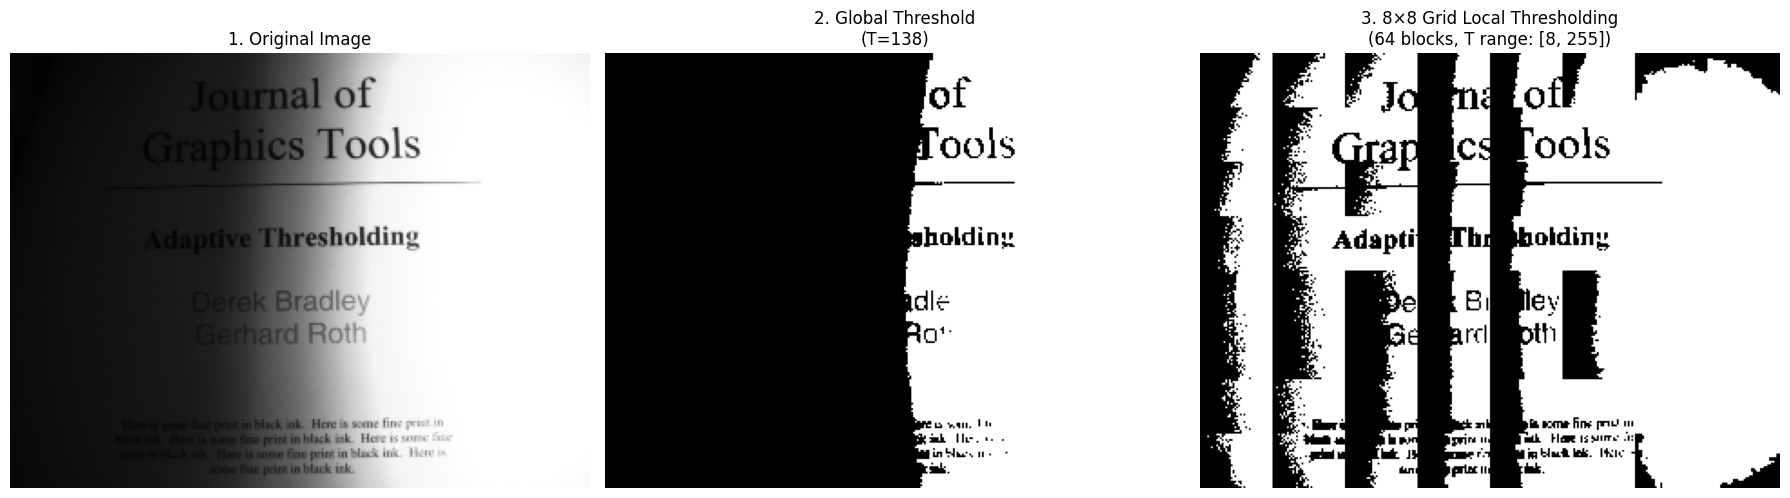


ANALYSIS: 8×8 Grid Benefits
✓ Global uses single threshold: 138
✓ 8×8 uses 64 adaptive thresholds: [8, 255]
✓ Better handling of non-uniform illumination
✓ Each block adapts to local content


In [37]:
# Experiment 3 Enhanced: 8×8 Grid Local Adaptive Thresholding

print("\n" + "=" * 60)
print("EXPERIMENT 3 ENHANCED: 8×8 Grid Local Adaptive Thresholding")
print("=" * 60)

def apply_grid_local_thresholding(image, grid_size=8):
    """
    Apply adaptive thresholding by dividing image into grid_size × grid_size blocks,
    applying iterative threshold to each block, then combining results.
    """
    
    # Convert to uint8 if necessary
    if image.dtype != np.uint8:
        img_uint8 = (image * 255).astype(np.uint8) if image.max() <= 1 else image.astype(np.uint8)
    else:
        img_uint8 = image.copy()
    
    height, width = img_uint8.shape
    
    block_h = height // grid_size
    block_w = width // grid_size
    
    result = np.zeros_like(img_uint8)
    threshold_map = np.zeros((grid_size, grid_size), dtype=int)
    
    print(f"\nProcessing {grid_size}×{grid_size} = {grid_size*grid_size} blocks...")
    print(f"Block size: {block_h}×{block_w} pixels\n")
    
    for i in range(grid_size):
        for j in range(grid_size):
            y1 = i * block_h
            y2 = (i + 1) * block_h if i < grid_size - 1 else height
            x1 = j * block_w
            x2 = (j + 1) * block_w if j < grid_size - 1 else width
            
            block = img_uint8[y1:y2, x1:x2]
            
            if block.size < 10 or block.std() < 1:
                threshold = int(img_uint8.mean())
                binary_block = np.where(block < threshold, 0, 255).astype(np.uint8)
            else:
                # Apply iterative threshold to this block
                threshold, binary_block, _ = getThreshold(block)
            
            # Store result
            result[y1:y2, x1:x2] = binary_block
            threshold_map[i, j] = threshold
    
    return result, threshold_map


try:
    book_img = io.imread('book.png')
    
    # Convert to grayscale if RGB
    if len(book_img.shape) == 3:
        book_gray = rgb2gray(book_img)
    else:
        book_gray = book_img
    
    # Global thresholding
    print("\n1. Global Thresholding:")
    global_threshold, global_binary, iterations = getThreshold(book_gray)
    print(f"   Threshold: {global_threshold}, Iterations: {iterations}")

    # 8×8 Grid thresholding
    print("\n2. 8×8 Grid (64 blocks):")
    local_8x8, threshold_map_8x8 = apply_grid_local_thresholding(book_gray, grid_size=8)
    print(f"   Threshold range: {threshold_map_8x8.min()} to {threshold_map_8x8.max()}")
    print(f"   Threshold variability: {threshold_map_8x8.std():.2f}")
    
    # Display comparison: Original, Global, 8×8 Grid
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Original
    axes[0].imshow(book_gray, cmap='gray')
    axes[0].set_title('1. Original Image')
    axes[0].axis('off')
    
    # Global threshold
    axes[1].imshow(global_binary, cmap='gray')
    axes[1].set_title(f'2. Global Threshold\n(T={global_threshold})')
    axes[1].axis('off')
    
    # 8×8 Grid result
    axes[2].imshow(local_8x8, cmap='gray')
    axes[2].set_title(f'3. 8×8 Grid Local Thresholding\n(64 blocks, T range: [{threshold_map_8x8.min()}, {threshold_map_8x8.max()}])')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Analysis
    print("\n" + "=" * 60)
    print("ANALYSIS: 8×8 Grid Benefits")
    print("=" * 60)
    print(f"✓ Global uses single threshold: {global_threshold}")
    print(f"✓ 8×8 uses 64 adaptive thresholds: [{threshold_map_8x8.min()}, {threshold_map_8x8.max()}]")
    print(f"✓ Better handling of non-uniform illumination")
    print(f"✓ Each block adapts to local content")
    print("=" * 60)
    
except FileNotFoundError:
    print("Warning: book.png not found")